In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

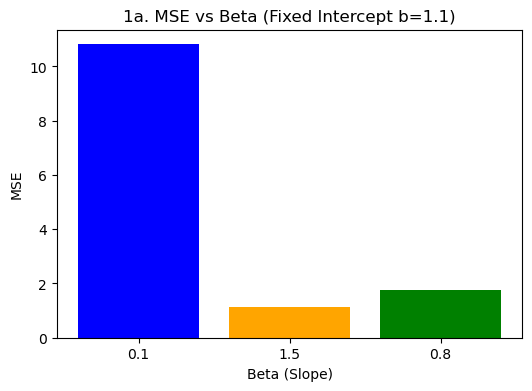

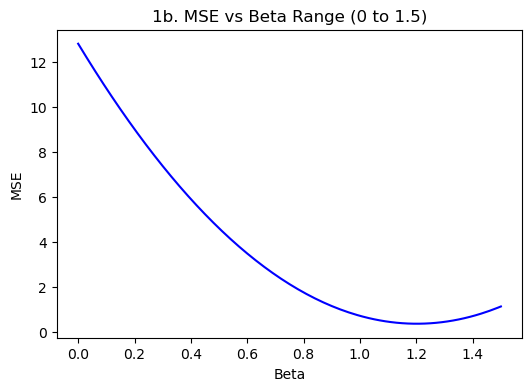

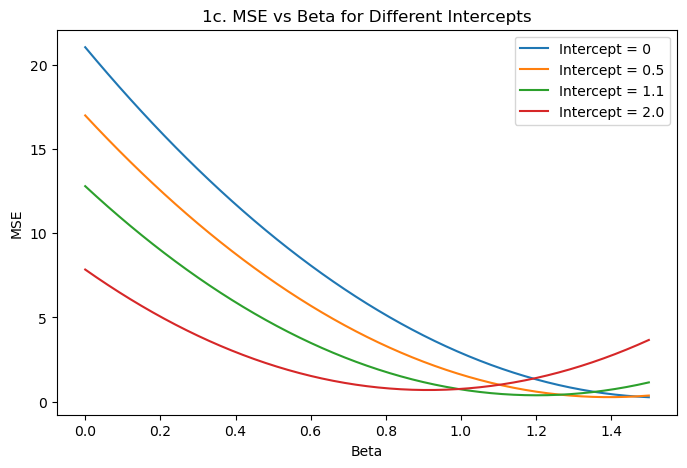

1d. Scikit-Learn Results:
Intercept (B0): -0.0356
Slope (B1): 1.5671
MSE: 0.2337


In [2]:
# Create and save the exact dataset from the PDF
data = {
    'experience': [1.2, 1.5, 1.9, 2.2, 2.4, 2.5, 2.8, 3.1, 3.3, 3.7, 4.2, 4.4],
    'salary': [1.7, 2.4, 2.3, 3.1, 3.7, 4.2, 4.4, 6.1, 5.4, 5.7, 6.4, 6.2]
}
df = pd.DataFrame(data)
df.to_csv('Salary_Data.csv', index=False)

X = df['experience'].values
y = df['salary'].values

# a. Check for beta = 0.1, 1.5, 0.8 with fixed intercept b = 1.1
b0 = 1.1
betas_a = [0.1, 1.5, 0.8]
mse_a = [mean_squared_error(y, b0 + b * X) for b in betas_a]

plt.figure(figsize=(6, 4))
plt.bar([str(b) for b in betas_a], mse_a, color=['blue', 'orange', 'green'])
plt.xlabel('Beta (Slope)'); plt.ylabel('MSE')
plt.title('1a. MSE vs Beta (Fixed Intercept b=1.1)')
plt.show()

# b. Try beta between 0 to 1.5 with increment 0.01, fixed intercept
betas_b = np.arange(0, 1.51, 0.01)
mse_b = [mean_squared_error(y, b0 + b * X) for b in betas_b]

plt.figure(figsize=(6, 4))
plt.plot(betas_b, mse_b, 'b-')
plt.xlabel('Beta'); plt.ylabel('MSE')
plt.title('1b. MSE vs Beta Range (0 to 1.5)')
plt.show()

# c. Try different values of intercept for slope beta 0 to 1.5
intercepts = [0, 0.5, 1.1, 2.0]
plt.figure(figsize=(8, 5))
for b_int in intercepts:
    mse_c = [mean_squared_error(y, b_int + b * X) for b in betas_b]
    plt.plot(betas_b, mse_c, label=f'Intercept = {b_int}')
plt.xlabel('Beta'); plt.ylabel('MSE')
plt.title('1c. MSE vs Beta for Different Intercepts')
plt.legend()
plt.show()

# d. Use scikit-learn and compare MSE
model = LinearRegression()
model.fit(X.reshape(-1, 1), y)
y_pred_sklearn = model.predict(X.reshape(-1, 1))
mse_sklearn = mean_squared_error(y, y_pred_sklearn)

print(f"1d. Scikit-Learn Results:")
print(f"Intercept (B0): {model.intercept_:.4f}")
print(f"Slope (B1): {model.coef_[0]:.4f}")
print(f"MSE: {mse_sklearn:.4f}")

## Q2

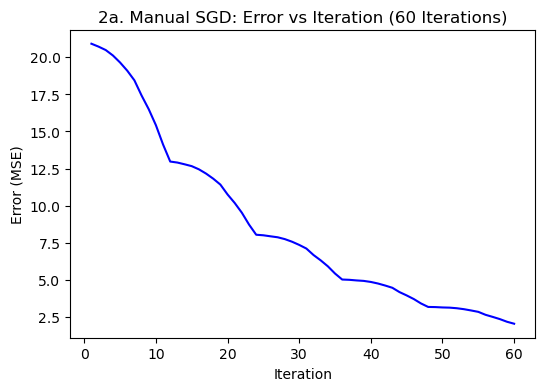

2b. Scikit-learn SGD Results:
Intercept (B0): 1.9548, Slope (B1): 0.6958


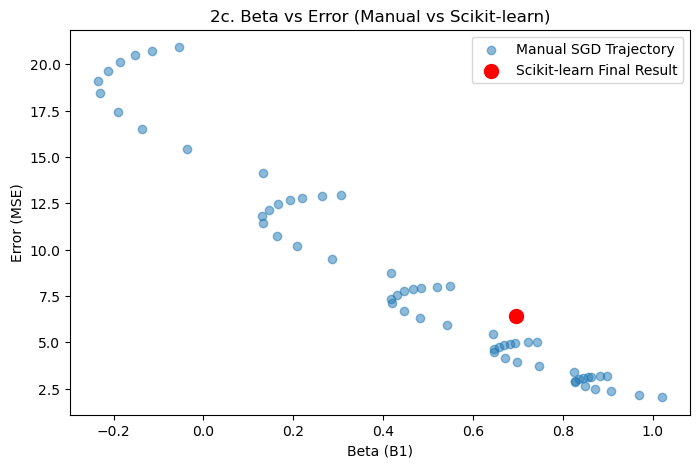

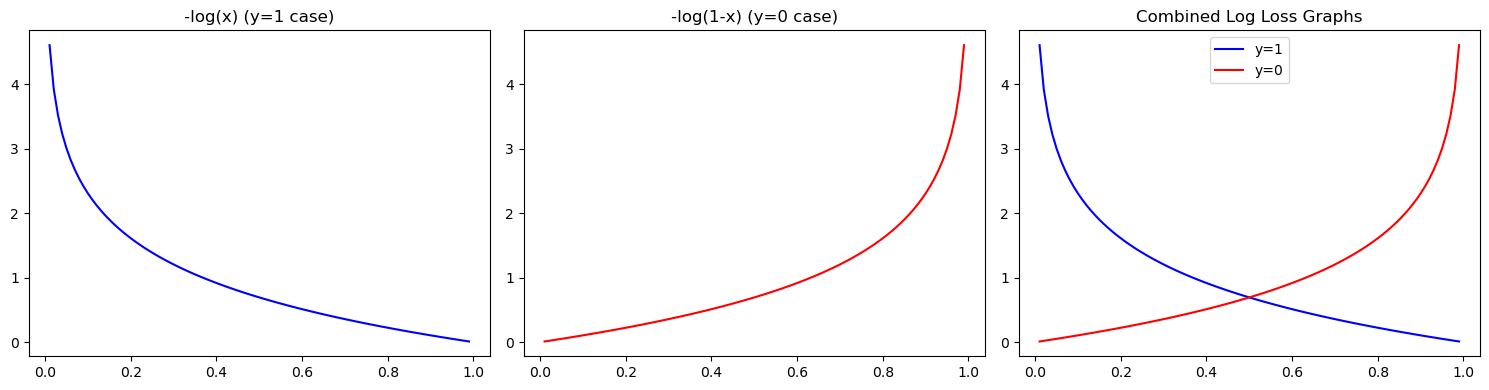

In [3]:
# Normalize X for better SGD convergence
X_norm = (X - X.mean()) / X.std()

# 60 iterations total (5 epochs * 12 samples = 60)
epochs = 5
b0, b1 = 0.0, 0.0
lr = 0.01

b1_hist_man, mse_hist_man = [], []

for epoch in range(epochs):
    for i in range(len(X_norm)):
        # Calculate prediction and error
        y_pred = b0 + b1 * X_norm[i]
        error = y[i] - y_pred
        
        # Update weights
        b0 = b0 - lr * (-2 * error)
        b1 = b1 - lr * (-2 * error * X_norm[i])
        
        # Track history
        b1_hist_man.append(b1)
        mse_hist_man.append(mean_squared_error(y, b0 + b1 * X_norm))

# a. Plot graph of error versus iteration
plt.figure(figsize=(6, 4))
plt.plot(range(1, 61), mse_hist_man, 'b-')
plt.xlabel('Iteration'); plt.ylabel('Error (MSE)')
plt.title('2a. Manual SGD: Error vs Iteration (60 Iterations)')
plt.show()

# b. Use scikit-learn for 60 iterations (5 epochs)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.reshape(-1, 1))

sgd = SGDRegressor(max_iter=5, learning_rate='constant', eta0=0.01, random_state=42)
sgd.fit(X_scaled, y)
print("2b. Scikit-learn SGD Results:")
print(f"Intercept (B0): {sgd.intercept_[0]:.4f}, Slope (B1): {sgd.coef_[0]:.4f}")

# c. Plot Beta vs Error (Manual vs Sklearn)
plt.figure(figsize=(8, 5))
plt.scatter(b1_hist_man, mse_hist_man, label='Manual SGD Trajectory', alpha=0.5)
plt.scatter([sgd.coef_[0]], [mean_squared_error(y, sgd.predict(X_scaled))], 
            color='red', s=100, label='Scikit-learn Final Result', zorder=5)
plt.xlabel('Beta (B1)'); plt.ylabel('Error (MSE)')
plt.title('2c. Beta vs Error (Manual vs Scikit-learn)')
plt.legend()
plt.show()

# d. Plot separate and combined graphs of -log(x) and -log(1-x)
x_vals = np.linspace(0.01, 0.99, 100)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
# y = 1 case
ax1.plot(x_vals, -np.log(x_vals), 'b-')
ax1.set_title('-log(x) (y=1 case)')

# y = 0 case
ax2.plot(x_vals, -np.log(1 - x_vals), 'r-')
ax2.set_title('-log(1-x) (y=0 case)')

# Combined
ax3.plot(x_vals, -np.log(x_vals), 'b-', label='y=1')
ax3.plot(x_vals, -np.log(1 - x_vals), 'r-', label='y=0')
ax3.set_title('Combined Log Loss Graphs')
ax3.legend()
plt.tight_layout()
plt.show()

## Q3

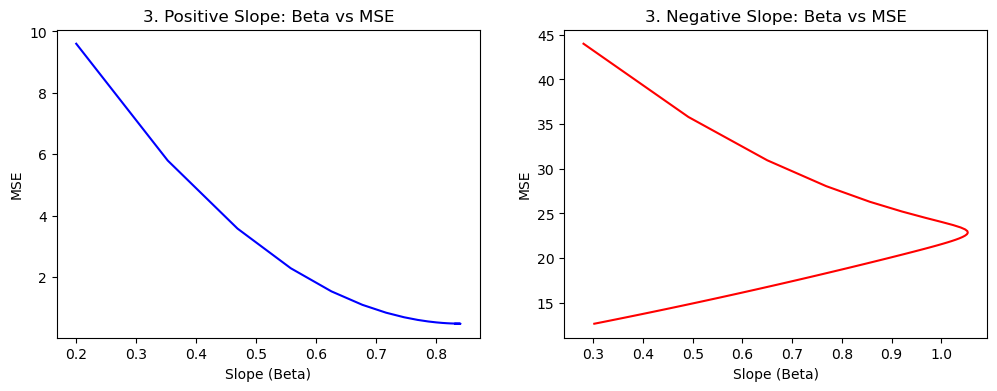

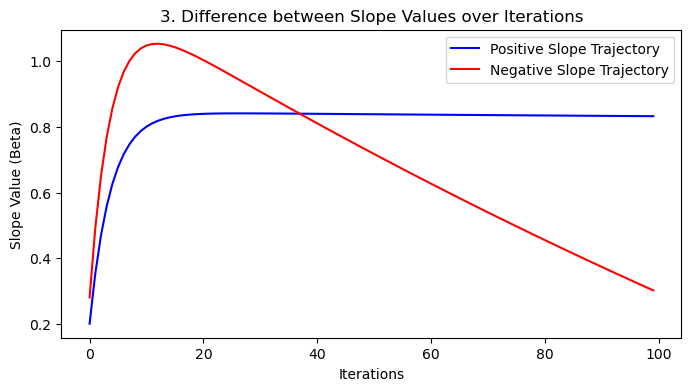

In [4]:
def slr_gd(X, y, epochs=100, lr=0.01):
    b0, b1 = 0, 0
    m = len(X)
    b1_hist, mse_hist = [], []
    for _ in range(epochs):
        y_pred = b0 + b1 * X
        b0 -= lr * (-2/m) * np.sum(y - y_pred)
        b1 -= lr * (-2/m) * np.sum((y - y_pred) * X)
        b1_hist.append(b1)
        mse_hist.append(mean_squared_error(y, y_pred))
    return b1_hist, mse_hist

# Data from Q3
x_pos, y_pos = np.array([1, 2, 4, 3, 5]), np.array([1, 3, 3, 2, 5])
x_neg, y_neg = np.array([1, 2, 3, 4, 5]), np.array([10, 8, 6, 4, 2])

b1_pos, mse_pos = slr_gd(x_pos, y_pos)
b1_neg, mse_neg = slr_gd(x_neg, y_neg)

# Plot: Beta vs MSE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(b1_pos, mse_pos, 'b-')
ax1.set_title('3. Positive Slope: Beta vs MSE')
ax1.set_xlabel('Slope (Beta)'); ax1.set_ylabel('MSE')

ax2.plot(b1_neg, mse_neg, 'r-')
ax2.set_title('3. Negative Slope: Beta vs MSE')
ax2.set_xlabel('Slope (Beta)'); ax2.set_ylabel('MSE')
plt.show()

# Plot: Slope values at different iterations
plt.figure(figsize=(8, 4))
plt.plot(range(100), b1_pos, 'b-', label='Positive Slope Trajectory')
plt.plot(range(100), b1_neg, 'r-', label='Negative Slope Trajectory')
plt.xlabel('Iterations'); plt.ylabel('Slope Value (Beta)')
plt.title('3. Difference between Slope Values over Iterations')
plt.legend()
plt.show()

## Q4

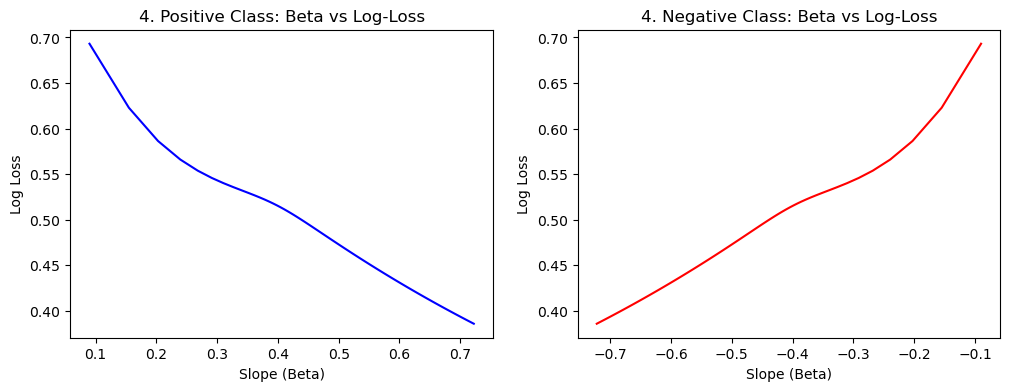

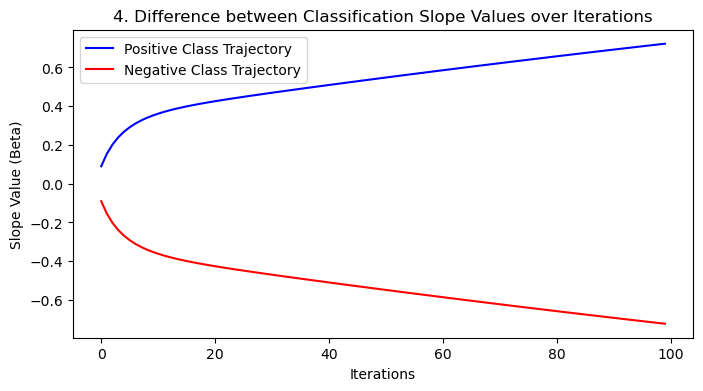

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_reg_gd(X, y, epochs=100, lr=0.1):
    b0, b1 = 0, 0
    m = len(X)
    b1_hist, loss_hist = [], []
    for _ in range(epochs):
        y_pred = sigmoid(b0 + b1 * X)
        b0 -= lr * (1/m) * np.sum(y_pred - y)
        b1 -= lr * (1/m) * np.sum((y_pred - y) * X)
        
        # Log loss with clipping to avoid numerical errors
        p = np.clip(y_pred, 1e-15, 1 - 1e-15)
        loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
        b1_hist.append(b1)
        loss_hist.append(loss)
    return b1_hist, loss_hist

# Data from Q4
x_pos_c, y_pos_c = np.array([1, 2, 3, 4, 5]), np.array([0, 0, 1, 1, 1])
x_neg_c, y_neg_c = np.array([1, 2, 3, 4, 5]), np.array([1, 1, 0, 0, 0])

b1_pos_c, loss_pos = log_reg_gd(x_pos_c, y_pos_c)
b1_neg_c, loss_neg = log_reg_gd(x_neg_c, y_neg_c)

# Plot: Beta vs Log-Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(b1_pos_c, loss_pos, 'b-')
ax1.set_title('4. Positive Class: Beta vs Log-Loss')
ax1.set_xlabel('Slope (Beta)'); ax1.set_ylabel('Log Loss')

ax2.plot(b1_neg_c, loss_neg, 'r-')
ax2.set_title('4. Negative Class: Beta vs Log-Loss')
ax2.set_xlabel('Slope (Beta)'); ax2.set_ylabel('Log Loss')
plt.show()

# Plot: Slope values at different iterations
plt.figure(figsize=(8, 4))
plt.plot(range(100), b1_pos_c, 'b-', label='Positive Class Trajectory')
plt.plot(range(100), b1_neg_c, 'r-', label='Negative Class Trajectory')
plt.xlabel('Iterations'); plt.ylabel('Slope Value (Beta)')
plt.title('4. Difference between Classification Slope Values over Iterations')
plt.legend()
plt.show()

## dp